In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import SelectFromModel
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
data_path = r"C:\Users\M\Downloads\talabat_enhanced_orders.csv"
df = pd.read_csv(data_path)
print("Shape:", df.shape)
df.head()

Shape: (100000, 23)


,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,...,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,1,U3522,358,485,Fried Chicken,3,273.72,2025-06-16 08:32:00,2025-06-16 09:11:00,39,...,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline
1,2,U9214,316,65,Sandwich,3,365.82,2025-06-03 21:27:00,2025-06-03 22:00:00,33,...,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online
2,3,U7307,357,309,Koshary,3,401.94,2025-06-01 14:48:00,2025-06-01 15:26:00,38,...,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online
3,4,U3612,420,32,Sushi,2,221.18,2025-06-13 02:30:00,2025-06-13 03:22:00,52,...,Car,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online
4,5,U3492,73,364,Koshary,5,355.55,2025-06-06 09:48:00,2025-06-06 10:32:00,44,...,Motorbike,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online


In [2]:
print("Missing values:")
print(df.isnull().sum())
print("\nDuplicated rows:", df.duplicated().sum())
print("\nData types:")
print(df.dtypes)

Missing values:
Order_ID                     0
User_ID                      0
Restaurant_ID                0
Driver_ID                    0
Item_Name                    0
Quantity                     0
Total_Price                  0
Order_Time                   0
Delivery_Time                0
Delivery_Duration_Minutes    0
City                         0
Payment_Method               0
Order_Status                 0
Driver_Vehicle               0
Restaurant_Lat               0
Restaurant_Lon               0
Customer_Lat                 0
Customer_Lon                 0
Driver_Lat                   0
Driver_Lon                   0
Delivery_Distance_km         0
Traffic_Level                0
Driver_Availability          0
dtype: int64

Duplicated rows: 0

Data types:
Order_ID                       int64
User_ID                       object
Restaurant_ID                  int64
Driver_ID                      int64
Item_Name                     object
Quantity                       int64
Tot

Order_Status
Delivered     85197
Cancelled      9812
In Transit     4991
Name: count, dtype: int64


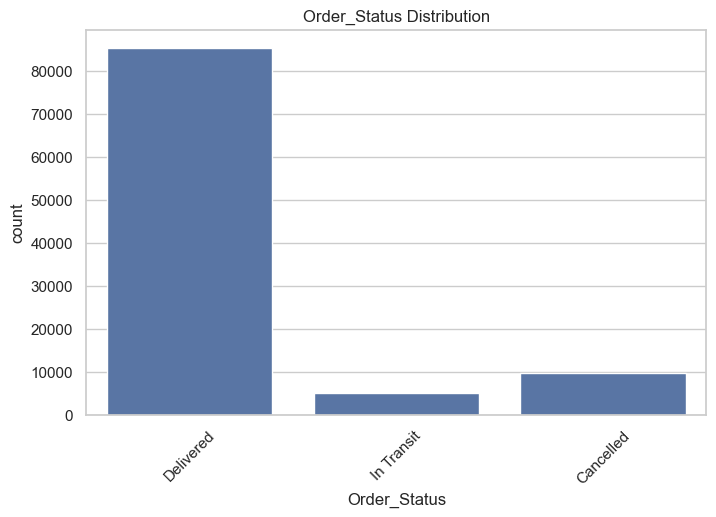

In [3]:
print(df["Order_Status"].value_counts())
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Order_Status")
plt.title("Order_Status Distribution")
plt.xticks(rotation=45)
plt.show()

In [4]:
df_fe = df.copy()
df_fe["Order_Time"] = pd.to_datetime(df_fe["Order_Time"])
df_fe["order_hour"] = df_fe["Order_Time"].dt.hour
df_fe["order_dayofweek"] = df_fe["Order_Time"].dt.dayofweek
df_fe["is_weekend"] = df_fe["order_dayofweek"].isin([4, 5]).astype(int)
df_fe["is_peak_hour"] = (
    df_fe["order_hour"].between(11, 14) |
    df_fe["order_hour"].between(17, 21)
).astype(int)
#TASK1
df_fe["value_per_item"] = df_fe["Total_Price"] / df_fe["Quantity"]
df_fe["price_band"] = pd.cut(
    df_fe["Total_Price"],
    bins=[0, 20, 50, 100, np.inf],
    labels=["low", "medium", "high", "very_high"]
)
df_fe.head()

df_fe = df.copy()
df_fe["Order_Time"] = pd.to_datetime(df_fe["Order_Time"])
df_fe["order_hour"] = df_fe["Order_Time"].dt.hour
df_fe["order_dayofweek"] = df_fe["Order_Time"].dt.dayofweek
df_fe["is_weekend"] = df_fe["order_dayofweek"].isin([4, 5]).astype(int)
df_fe["is_peak_hour"] = (
    df_fe["order_hour"].between(11, 14) |
    df_fe["order_hour"].between(17, 21)
).astype(int)
df_fe["value_per_item"] = df_fe["Total_Price"] / df_fe["Quantity"]
df_fe["price_band"] = pd.cut(
    df_fe["Total_Price"],
    bins=[0, 20, 50, 100, np.inf],
    labels=["low", "medium", "high", "very_high"]
)
df_fe.head()

,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,...,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability,order_hour,order_dayofweek,is_weekend,is_peak_hour,value_per_item,price_band
0,1,U3522,358,485,Fried Chicken,3,273.72,2025-06-16 08:32:00,2025-06-16 09:11:00,39,...,29.910664,1.666106,High,Offline,8,0,0,0,91.24,very_high
1,2,U9214,316,65,Sandwich,3,365.82,2025-06-03 21:27:00,2025-06-03 22:00:00,33,...,31.502380,2.738698,Low,Online,21,1,0,1,121.94,very_high
2,3,U7307,357,309,Koshary,3,401.94,2025-06-01 14:48:00,2025-06-01 15:26:00,38,...,31.189458,2.929079,Medium,Online,14,6,0,1,133.98,very_high
3,4,U3612,420,32,Sushi,2,221.18,2025-06-13 02:30:00,2025-06-13 03:22:00,52,...,31.401187,0.677498,Low,Online,2,4,1,0,110.59,very_high
4,5,U3492,73,364,Koshary,5,355.55,2025-06-06 09:48:00,2025-06-06 10:32:00,44,...,31.389315,1.994769,High,Online,9,4,1,0,71.11,very_high


Order_Status
Delivered     85197
Cancelled      9812
In Transit     4991
Name: count, dtype: int64


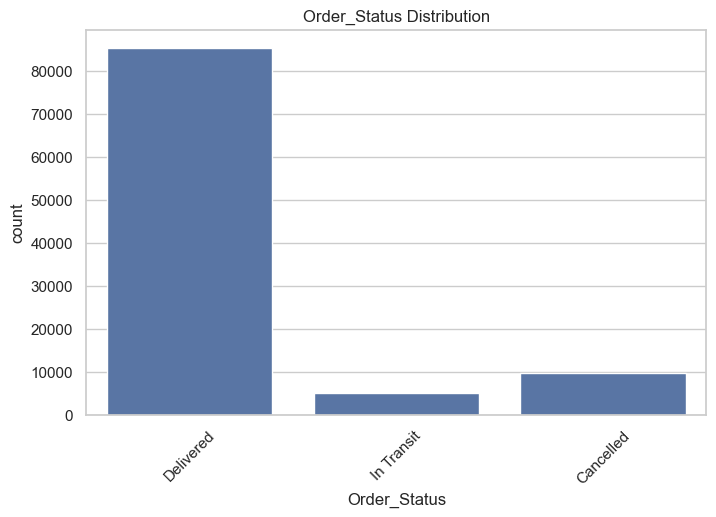

In [6]:
print(df["Order_Status"].value_counts())
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Order_Status")
plt.title("Order_Status Distribution")
plt.xticks(rotation=45)
plt.show()

In [8]:
top_k = 30
top_items = df_fe["Item_Name"].value_counts().nlargest(top_k).index
df_fe["Item_Name_reduced"] = df_fe["Item_Name"].apply(
    lambda x: x if x in top_items else "Other"
)
print(df_fe["Item_Name_reduced"].value_counts().head(15))

Item_Name_reduced
Shawarma         11320
Pizza            11229
Fried Chicken    11171
Burger           11129
Pasta            11077
Sandwich         11061
Koshary          11033
Sushi            10990
Salad            10990
Name: count, dtype: int64


In [9]:
drop_cols = [
    "Order_ID",
    "User_ID",
    "Restaurant_ID",
    "Driver_ID",
    "Order_Time",
    "Delivery_Time",
    "Delivery_Duration_Minutes",
    "Item_Name"   # we use Item_Name_reduced instead
]

existing_drop_cols = [col for col in drop_cols if col in df_fe.columns]
df_model = df_fe.drop(columns=existing_drop_cols)

print(df_model.columns)
df_model.head()

Index(['Quantity', 'Total_Price', 'City', 'Payment_Method', 'Order_Status',
       'Driver_Vehicle', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat',
       'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km',
       'Traffic_Level', 'Driver_Availability', 'order_hour', 'order_dayofweek',
       'is_weekend', 'is_peak_hour', 'value_per_item', 'price_band',
       'Item_Name_reduced'],
      dtype='object')


,Quantity,Total_Price,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,...,Delivery_Distance_km,Traffic_Level,Driver_Availability,order_hour,order_dayofweek,is_weekend,is_peak_hour,value_per_item,price_band,Item_Name_reduced
0,3,273.72,Alexandria,Wallet,Delivered,Motorbike,31.195082,29.921931,31.191404,29.904982,...,1.666106,High,Offline,8,0,0,0,91.24,very_high,Fried Chicken
1,3,365.82,Zagazig,Credit Card,Delivered,Motorbike,30.605729,31.503079,30.586047,31.485820,...,2.738698,Low,Online,21,1,0,1,121.94,very_high,Sandwich
2,3,401.94,Assiut,Cash,In Transit,Car,27.190180,31.177741,27.164869,31.169218,...,2.929079,Medium,Online,14,6,0,1,133.98,very_high,Koshary
3,2,221.18,Mansoura,Cash,Delivered,Car,31.041846,31.381229,31.035773,31.380440,...,0.677498,Low,Online,2,4,1,0,110.59,very_high,Sushi
4,5,355.55,Mansoura,Wallet,Delivered,Motorbike,31.024141,31.376104,31.026023,31.396881,...,1.994769,High,Online,9,4,1,0,71.11,very_high,Koshary


In [10]:
X = df_model.drop("Order_Status", axis=1)
y = df_model["Order_Status"]
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['City', 'Payment_Method', 'Driver_Vehicle', 'Traffic_Level', 'Driver_Availability', 'price_band', 'Item_Name_reduced']
Numerical columns: ['Quantity', 'Total_Price', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat', 'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km', 'order_hour', 'order_dayofweek', 'is_weekend', 'is_peak_hour', 'value_per_item']


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (80000, 21)
X_test shape: (20000, 21)


In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        n_estimators=50,
        max_depth=10,
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.85195

Classification Report:

              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00      1963
   Delivered       0.85      1.00      0.92     17039
  In Transit       0.00      0.00      0.00       998

    accuracy                           0.85     20000
   macro avg       0.28      0.33      0.31     20000
weighted avg       0.73      0.85      0.78     20000



In [13]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.85195

Classification Report:

              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00      1963
   Delivered       0.85      1.00      0.92     17039
  In Transit       0.00      0.00      0.00       998

    accuracy                           0.85     20000
   macro avg       0.28      0.33      0.31     20000
weighted avg       0.73      0.85      0.78     20000



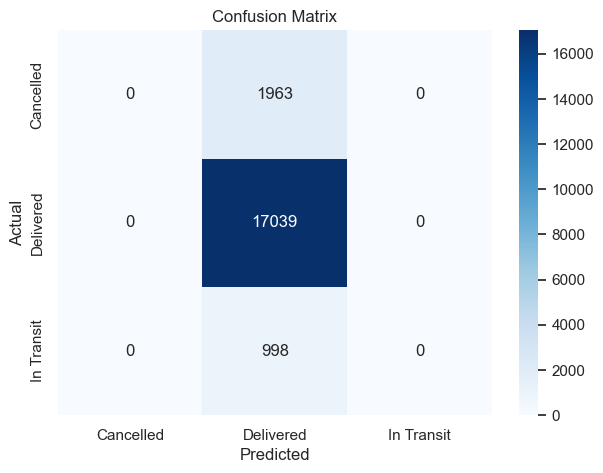

In [14]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y),
            yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [15]:
ohe = model.named_steps["preprocessor"].named_transformers_["cat"]
encoded_cat_features = ohe.get_feature_names_out(categorical_cols)
all_feature_names = list(encoded_cat_features) + numerical_cols
importances = model.named_steps["classifier"].feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df.head(10))

                 Feature  Importance
38  Delivery_Distance_km    0.089841
35          Customer_Lon    0.085787
36            Driver_Lat    0.083672
32        Restaurant_Lat    0.083671
34          Customer_Lat    0.083576
37            Driver_Lon    0.081000
33        Restaurant_Lon    0.080666
43        value_per_item    0.076776
31           Total_Price    0.074757
39            order_hour    0.041647


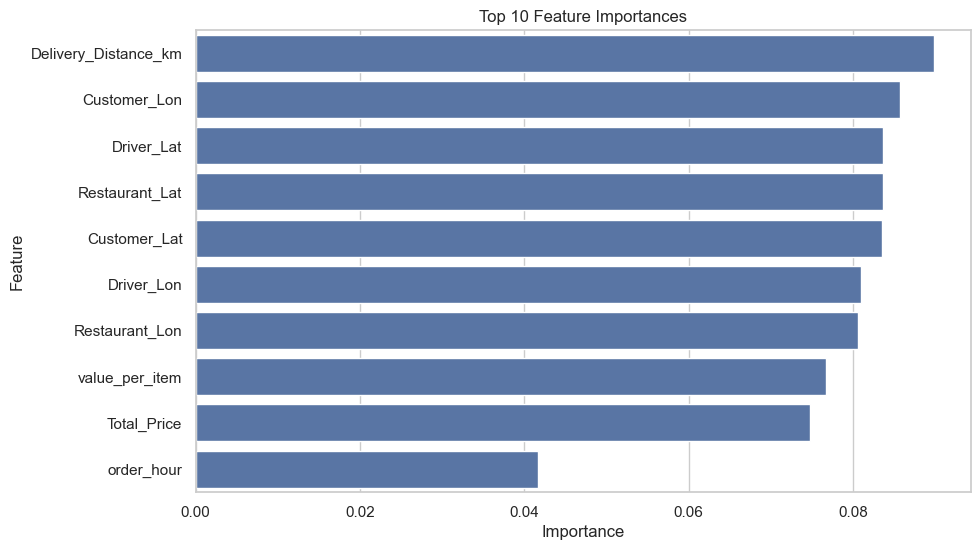

In [16]:
top_n = 10
top_features = feature_importance_df.head(top_n)
plt.figure(figsize=(10,6))
sns.barplot(data=top_features, x="Importance", y="Feature")
plt.title(f"Top {top_n} Feature Importances")
plt.show()

In [17]:
X_train_transformed = model.named_steps["preprocessor"].transform(X_train)
X_test_transformed = model.named_steps["preprocessor"].transform(X_test)
rf_base = RandomForestClassifier(random_state=42, n_estimators=200)
rf_base.fit(X_train_transformed, y_train)
selector = SelectFromModel(rf_base, threshold="median", prefit=True)
X_train_selected = selector.transform(X_train_transformed)
X_test_selected = selector.transform(X_test_transformed)
rf_selected = RandomForestClassifier(random_state=42, n_estimators=200)
rf_selected.fit(X_train_selected, y_train)
y_pred_selected = rf_selected.predict(X_test_selected)
acc_selected = accuracy_score(y_test, y_pred_selected)
print("Accuracy after feature selection:", acc_selected)
print("\nClassification Report after feature selection:\n")
print(classification_report(y_test, y_pred_selected))

Accuracy after feature selection: 0.85195

Classification Report after feature selection:

              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00      1963
   Delivered       0.85      1.00      0.92     17039
  In Transit       0.00      0.00      0.00       998

    accuracy                           0.85     20000
   macro avg       0.28      0.33      0.31     20000
weighted avg       0.73      0.85      0.78     20000



In [18]:
#Task 3 - Compare Different top_k Values

results = []

for k in [10, 30, 50]:
    temp_df = df.copy()
    
    temp_df["Order_Time"] = pd.to_datetime(temp_df["Order_Time"])
    temp_df["order_hour"] = temp_df["Order_Time"].dt.hour
    temp_df["order_dayofweek"] = temp_df["Order_Time"].dt.dayofweek
    temp_df["is_weekend"] = temp_df["order_dayofweek"].isin([4, 5]).astype(int)
    temp_df["is_peak_hour"] = (
        temp_df["order_hour"].between(11, 14) |
        temp_df["order_hour"].between(17, 21)
    ).astype(int)
    temp_df["value_per_item"] = temp_df["Total_Price"] / temp_df["Quantity"]
    temp_df["price_band"] = pd.cut(
        temp_df["Total_Price"],
        bins=[0, 20, 50, 100, np.inf],
        labels=["low", "medium", "high", "very_high"]
    )
    
    top_items_k = temp_df["Item_Name"].value_counts().nlargest(k).index
    temp_df["Item_Name_reduced"] = temp_df["Item_Name"].apply(
        lambda x: x if x in top_items_k else "Other"
    )
    
    existing_drop_cols = [col for col in drop_cols if col in temp_df.columns]
    temp_df = temp_df.drop(columns=existing_drop_cols)
    
    X_temp = temp_df.drop("Order_Status", axis=1)
    y_temp = temp_df["Order_Status"]
    
    cat_cols = X_temp.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = X_temp.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
    
    X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
        X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
    )
    
    preprocessor_t = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
            ("num", "passthrough", num_cols)
        ]
    )
    
    model_t = Pipeline(steps=[
        ("preprocessor", preprocessor_t),
        ("classifier", RandomForestClassifier(random_state=42, n_estimators=200))
    ])
    
    model_t.fit(X_train_t, y_train_t)
    y_pred_t = model_t.predict(X_test_t)
    acc_t = accuracy_score(y_test_t, y_pred_t)
    
    results.append({"top_k": k, "accuracy": acc_t})

results_df = pd.DataFrame(results)
results_df

,top_k,accuracy
0,10,0.85195
1,30,0.85195
2,50,0.85195


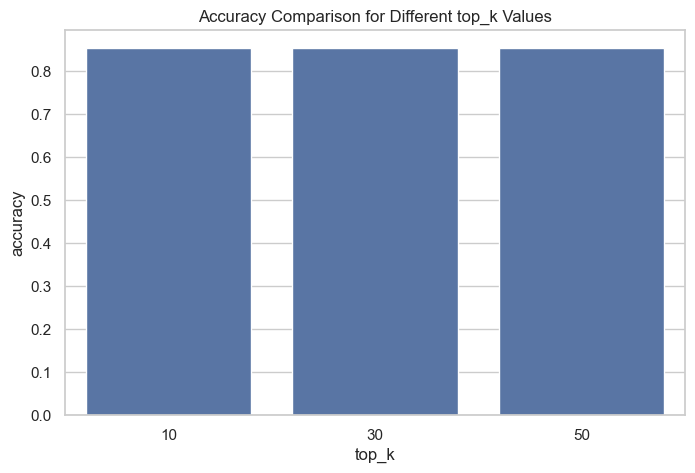

In [19]:
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="top_k", y="accuracy")
plt.title("Accuracy Comparison for Different top_k Values")
plt.show()